# Customer Retention & Churn Analysis

## Business Problem
Customer acquisition is expensive, yet repeat purchase behavior is low. 
This analysis investigates why customers fail to return, quantifies the revenue impact of low retention, 
and identifies actionable levers to improve customer lifetime value.

## Objectives
- Compare first-time and repeat customer behavior
- Measure revenue contribution from repeat buyers
- Analyze time between purchases
- Perform cohort-based retention analysis
- Define and quantify customer churn

## Dataset
The analysis uses a cleaned and validated e-commerce dataset containing:
- Order-level transactions
- Customer identifiers
- Purchase timestamps
- Product and delivery attributes

All preprocessing, validation, and missing value treatments were completed in earlier notebooks.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("cleaned_ecommerce_data.csv").copy()



In [23]:
df['order_purchase_timestamp'] = pd.to_datetime(
    df['order_purchase_timestamp'],
    errors='coerce'
)


In [2]:
#FIRST-TIME VS REPEAT BUYERS

In [8]:
customer_orders = (
    df.groupby('customer_unique_id')['order_id']
      .nunique()
      .reset_index(name='order_count')
)
customer_orders.sort_values(by='order_count', ascending=False).head()


,customer_unique_id,order_count
51431,8d50f5eadf50201ccdcedfb9e2ac8455,15
22779,3e43e6105506432c953e165fb2acf44c,9
36706,6469f99c1f9dfae7733b25662e7f1782,7
73921,ca77025e7201e3b30c44b472ff346268,7
10060,1b6c7548a2a1f9037c1fd3ddfed95f33,7


In [11]:
customer_orders['customer_type']= customer_orders['order_count'].apply(
    lambda x : 'Repeat' if x > 1 else 'First-time'
)
customer_orders['customer_type'].head()

0    First-time
1    First-time
2    First-time
3    First-time
4    First-time
Name: customer_type, dtype: object

In [14]:
df = df.merge(customer_orders[['customer_unique_id', 'customer_type']],
              on = 'customer_unique_id',
              how= 'left'
)
df.shape

(110197, 31)

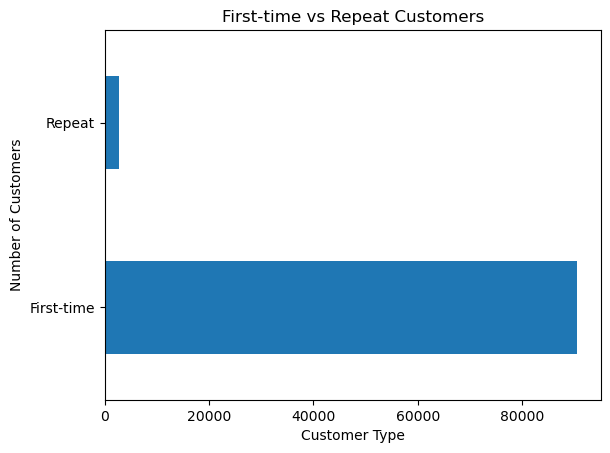

In [16]:
df[['customer_unique_id', 'customer_type']].drop_duplicates()['customer_type'] \
    .value_counts().plot(kind='barh')

plt.title("First-time vs Repeat Customers")
plt.xlabel("Customer Type")
plt.ylabel("Number of Customers")
plt.show()


In [17]:
#REVENUE CONTRIBUTION BY REPEAT CUSTOMERS

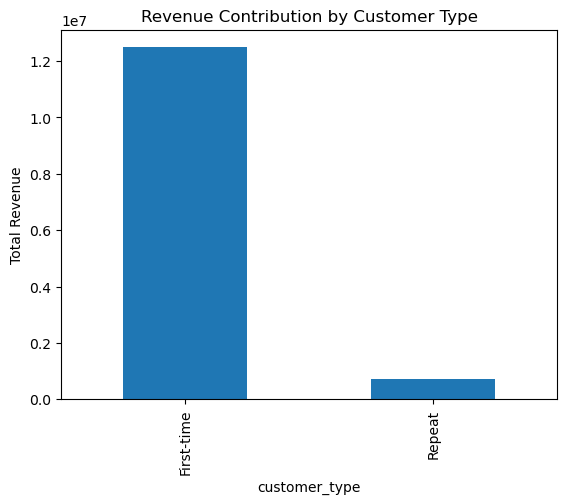

In [18]:
revenue_by_type = (
    df.groupby('customer_type')['revenue'].sum()
)

revenue_by_type.plot(kind='bar')
plt.title("Revenue Contribution by Customer Type")
plt.ylabel("Total Revenue")
plt.show()

In [19]:
#TIME BETWEEN PURCHASES


In [24]:
df_sorted = df.sort_values(['customer_unique_id', 'order_purchase_timestamp'])

df_sorted['days_between_orders'] = (
    df_sorted.groupby('customer_unique_id')['order_purchase_timestamp']
    .diff()
    .dt.days
)



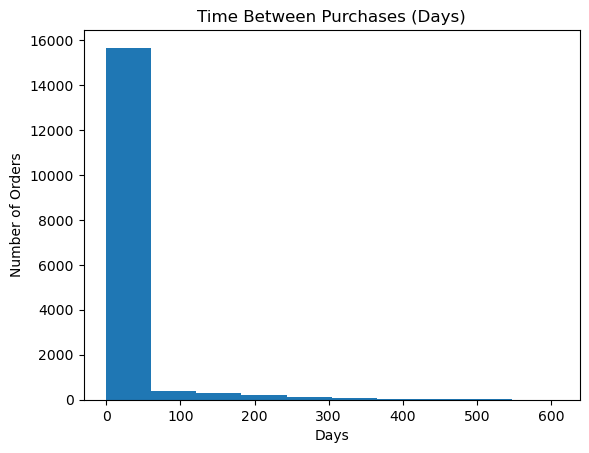

In [28]:
df_sorted['days_between_orders'].dropna().plot(kind='hist', bins=10)
plt.title("Time Between Purchases (Days)")
plt.xlabel("Days")
plt.ylabel("Number of Orders")
plt.show()


In [29]:
#MONTHLY COHORT ANALYSIS (RETENTION DECAY)

In [32]:
df['order_month'] = df['order_purchase_timestamp'].dt.to_period('M')

df['cohort'] = (df.groupby('customer_unique_id')['order_month'].transform('min'))
df['cohort_index'] = ((df['order_month'] - df['cohort']).apply(lambda x : x.n))

cohort_data = (df.groupby(['cohort', 'cohort_index'])['customer_unique_id'].nunique().reset_index())

cohort_pivot = cohort_data.pivot(
    index='cohort',
    columns='cohort_index',
    values='customer_unique_id'
)

Text(0, 0.5, 'Active Customers')

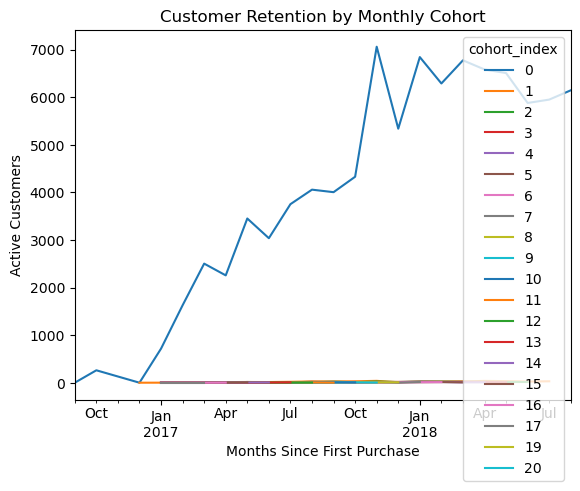

In [33]:
cohort_pivot.plot()
plt.title("Customer Retention by Monthly Cohort")
plt.xlabel("Months Since First Purchase")
plt.ylabel("Active Customers")

In [34]:
cohort_pivot

cohort_index,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,19,20
cohort,,,,,,,,,,,,,,,,,,,,
2016-09,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-10,262.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,1.0,NaN,1.0,NaN,1.0,NaN,1.0,NaN,1.0,2.0,2.0
2016-12,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-01,717.0,2.0,2.0,1.0,3.0,1.0,3.0,1.0,1.0,NaN,3.0,1.0,5.0,3.0,1.0,1.0,2.0,3.0,1.0,NaN
2017-02,1628.0,3.0,5.0,2.0,7.0,2.0,4.0,3.0,2.0,3.0,2.0,5.0,2.0,3.0,2.0,1.0,1.0,3.0,NaN,NaN
2017-03,2503.0,11.0,9.0,10.0,9.0,4.0,4.0,8.0,8.0,2.0,9.0,3.0,5.0,3.0,4.0,6.0,2.0,3.0,NaN,NaN
2017-04,2256.0,14.0,5.0,4.0,6.0,6.0,8.0,7.0,7.0,4.0,6.0,2.0,1.0,1.0,2.0,2.0,3.0,NaN,NaN,NaN
2017-05,3451.0,16.0,16.0,10.0,10.0,11.0,14.0,5.0,9.0,9.0,9.0,12.0,8.0,1.0,6.0,7.0,NaN,NaN,NaN,NaN
2017-06,3037.0,15.0,12.0,13.0,9.0,12.0,11.0,7.0,4.0,6.0,9.0,11.0,5.0,5.0,7.0,NaN,NaN,NaN,NaN,NaN


In [ ]:
# CHURN PROXY DEFINITION

In [35]:
last_purchase = (
    df.groupby('customer_unique_id')['order_purchase_timestamp']
      .max()
)

analysis_date = df['order_purchase_timestamp'].max()

churned_customers = (
    (analysis_date - last_purchase).dt.days > 90
)

churn_rate = churned_customers.mean() * 100
churn_rate

# A high churn rate confirms that customers disengage quickly after their first purchase.

np.float64(80.08740547141112)

# 📌 Customer Retention & Churn Analysis — Summary & Insights

## Business Question
Customer acquisition is expensive. Why is repeat purchase low, and how does it impact revenue?

---

## Key Findings

### 1️⃣ First-Time vs Repeat Customers
- The customer base is overwhelmingly dominated by **first-time buyers**.
- Repeat customers form a **very small fraction** of total customers.
- This indicates weak customer stickiness after the initial purchase.

📉 **Implication:** Growth is acquisition-driven rather than retention-driven, increasing long-term costs.

---

### 2️⃣ Time Between Purchases
- Most repeat purchases occur within **0–60 days** of the first order.
- Beyond this window, purchase frequency drops sharply.
- Very few customers return after **90+ days**.

⏳ **Implication:** There is a narrow re-engagement window where retention efforts must be focused.

---

### 3️⃣ Monthly Cohort Retention Analysis
- Cohort curves show **steep drop-off after the first purchase month**.
- Retention decays rapidly across all cohorts with minimal long-term recovery.
- Later cohorts do not demonstrate improvement over earlier ones.

📊 **Implication:** Retention issues are structural, not cohort-specific or seasonal.

---

### 4️⃣ Revenue Contribution by Customer Type
- **First-time customers generate the majority of revenue**.
- Repeat customers contribute **disproportionately low revenue** despite higher lifetime potential.

💰 **Implication:** The business is failing to capitalize on high-ROI repeat purchases.

---

### 5️⃣ Churn Proxy Analysis
- Customers were labeled as churned if inactive for **90+ days**.
- **Estimated churn rate ≈ 80%**, indicating severe post-purchase disengagement.

🚨 **Implication:** Most customers do not form repeat buying habits.

---

## Root Causes Identified
- Lack of post-purchase engagement
- No effective retention or reactivation strategy
- Poor incentive for second purchase
- Customer lifecycle not actively managed

---

## Strategic Recommendations

### 🎯 Short-Term Actions
- Launch targeted **30–60 day reactivation campaigns**
- Offer **second-purchase incentives**
- Introduce order-follow-up communication flows

### 🧠 Medium-Term Actions
- Segment customers based on purchase intervals
- Personalize offers using product/category affinity
- Implement loyalty or rewards mechanisms

### 📈 Long-Term Actions
- Shift KPIs from pure acquisition to **Customer Lifetime Value (CLV)**
- Track retention by cohort as a core performance metric
- Build churn prediction models for proactive retention

---

## Final Takeaway
Low repeat purchase is driven by **rapid customer churn after the first order**, resulting in overdependence on costly acquisition. Improving retention—even marginally—offers a significant opportunity to increase revenue efficiency and long-term growth.

---

**This analysis directly supports data-driven retention strategy decisions and highlights clear levers for business impact.**
